[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_06/notebook_6_7_gradcam.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# 6.7 GradCAM: Visualizing What CNNs Learn

## Learning Objectives
1. Understand the "black box" problem in medical AI
2. Implement Gradient-weighted Class Activation Mapping (GradCAM)
3. Visualize which image regions influence CNN decisions
4. Detect spurious correlations and dataset biases
5. Compare attention patterns across different CNN layers
6. Apply GradCAM to clinical decision-making

## Clinical Context

**The Interpretability Problem:**

A CNN achieves 95% accuracy detecting pneumonia from chest X-rays. But:
- **Is it looking at lung infiltrates?** ✅ (Correct reasoning)
- **Or hospital bed rails in the image?** ❌ (Spurious correlation)

**Why GradCAM Matters:**
- **Clinical trust**: Radiologists need to see what the AI "sees"
- **Regulatory approval**: FDA requires explainability for high-risk devices
- **Debugging**: Detect when models learn shortcuts instead of pathology
- **Education**: Teach clinicians which features matter

**Journey 5 (Priya - Melanoma)**: GradCAM reveals if the CNN correctly focuses on lesion characteristics (asymmetry, border irregularity, color variation) or spurious features (rulers, skin markings).

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from skimage import transform
from skimage.util import random_noise
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Part 1: Understanding the Black Box Problem

### What is the Black Box Problem?

**Problem**: CNNs are opaque - we can't easily see WHY they make predictions.

**Example scenario:**
```
Input: Chest X-ray
CNN: "95% probability of pneumonia"
Clinician: "Why? What are you seeing?"
CNN: ¯\_(ツ)_/¯
```

**Consequences:**
1. **Lack of trust**: Clinicians won't adopt AI they don't understand
2. **Hidden biases**: Model might use shortcuts (e.g., hospital branding)
3. **Regulatory barriers**: FDA requires explainability
4. **Missed learning**: Can't improve clinical workflows

### What is GradCAM?

**Gradient-weighted Class Activation Mapping (GradCAM)**:
- Generates **heatmap** showing which pixels influenced the prediction
- Uses gradients flowing back from output to convolutional layers
- Works for any CNN architecture (no modifications needed!)

**Key Idea:**
$$
L_{\text{GradCAM}}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)
$$

Where:
- $L_{\text{GradCAM}}^c$ = GradCAM heatmap for class $c$
- $A^k$ = Activation maps from convolutional layer
- $\alpha_k^c = \frac{1}{Z}\sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}$ = Importance weights (gradients)
- $\text{ReLU}$ = Keep only positive contributions

## Part 2: Simple CNN Implementation

First, let's build a simple CNN to understand GradCAM mechanics:

In [2]:
class SimpleCNN:
    """
    Simple CNN for educational purposes.
    In practice, use PyTorch/TensorFlow with automatic differentiation.
    """

    def __init__(self, input_shape=(128, 128)):
        self.input_shape = input_shape

        # Initialize random weights for demonstration
        # Layer 1: 8 filters, 5×5
        self.conv1_filters = np.random.randn(8, 5, 5) * 0.1

        # Layer 2: 16 filters, 3×3
        self.conv2_filters = np.random.randn(16, 3, 3) * 0.1

        # Layer 3: 32 filters, 3×3 (target layer for GradCAM)
        self.conv3_filters = np.random.randn(32, 3, 3) * 0.1

        # Store activations for GradCAM
        self.activations = {}
        self.gradients = {}

        print("✓ SimpleCNN initialized")
        print(f"  Input shape: {input_shape}")
        print(f"  Architecture: Conv1(8) → Conv2(16) → Conv3(32) → Flatten → Dense(2)")

    def conv_forward(self, image, filters, layer_name):
        """Forward pass through convolutional layer."""
        num_filters = filters.shape[0]
        feature_maps = []

        for i in range(num_filters):
            # Simple convolution (using correlation for speed)
            conv_result = ndimage.correlate(image, filters[i], mode='constant')
            # ReLU activation
            activated = np.maximum(0, conv_result)
            feature_maps.append(activated)

        output = np.array(feature_maps)

        # Store activations for GradCAM
        self.activations[layer_name] = output

        return output

    def forward(self, image):
        """Forward pass through entire network."""
        # Layer 1
        x = self.conv_forward(image, self.conv1_filters, 'conv1')
        # Max pooling 2×2
        x = x[:, ::2, ::2]

        # Layer 2 (apply to each channel)
        x_list = []
        for i in range(x.shape[0]):
            conv_result = self.conv_forward(x[i], self.conv2_filters, f'conv2_ch{i}')
            x_list.append(conv_result)
        x = np.mean(x_list, axis=0)  # Average across input channels
        # Max pooling 2×2
        x = x[:, ::2, ::2]

        # Layer 3 (target layer for GradCAM)
        x_list = []
        for i in range(x.shape[0]):
            conv_result = self.conv_forward(x[i], self.conv3_filters, f'conv3_ch{i}')
            x_list.append(conv_result)
        x = np.mean(x_list, axis=0)  # Average across input channels

        # Store final conv layer for GradCAM
        self.final_conv_output = x

        # Global average pooling
        x_gap = np.mean(x, axis=(1, 2))

        # Fully connected layer (simulated with random weights)
        fc_weights = np.random.randn(2, x_gap.shape[0]) * 0.1
        logits = fc_weights @ x_gap

        # Softmax
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)

        return probs

print("SimpleCNN class defined.")

SimpleCNN class defined.


## Part 3: Implementing GradCAM from Scratch

### GradCAM Algorithm

**Steps:**
1. Forward pass: Get predictions and save feature maps
2. Backward pass: Compute gradients w.r.t. target class
3. Weight feature maps by gradients (importance)
4. Average weighted maps and apply ReLU
5. Upsample to input image size
6. Overlay on original image

In [ ]:
def compute_gradcam(feature_maps, gradients):
    """
    Compute GradCAM heatmap from feature maps and gradients.

    Args:
        feature_maps: Activations from target conv layer, shape (num_filters, H, W)
        gradients: Gradients of class score w.r.t. feature maps, same shape

    Returns:
        GradCAM heatmap, shape (H, W)
    """
    # Step 1: Global average pooling of gradients
    # α_k^c = (1/Z) Σ_i Σ_j ∂y^c/∂A_ij^k
    weights = np.mean(gradients, axis=(1, 2))  # Shape: (num_filters,)

    # Step 2: Weighted combination of feature maps
    # L_GradCAM = Σ_k α_k^c * A^k
    gradcam = np.zeros(feature_maps.shape[1:])
    for i, weight in enumerate(weights):
        gradcam += weight * feature_maps[i]

    # Step 3: Apply ReLU (only positive contributions)
    gradcam = np.maximum(gradcam, 0)

    # Step 4: Normalize to [0, 1]
    if gradcam.max() > 0:
        gradcam = gradcam / gradcam.max()

    return gradcam

def upsample_gradcam(gradcam, target_size):
    """
    Upsample GradCAM heatmap to match input image size.
    """
    return transform.resize(gradcam, target_size, order=1, preserve_range=True)

def overlay_gradcam(image, gradcam_heatmap, alpha=0.4, colormap='jet'):
    """
    Overlay GradCAM heatmap on original image.

    Args:
        image: Original grayscale image
        gradcam_heatmap: GradCAM heatmap (same size as image)
        alpha: Transparency of overlay (0=transparent, 1=opaque)
        colormap: Matplotlib colormap name

    Returns:
        RGB image with GradCAM overlay
    """
    # Convert grayscale to RGB
    image_rgb = np.stack([image]*3, axis=-1)

    # Apply colormap to heatmap
    import matplotlib.cm as cm
    cmap = cm.get_cmap(colormap)
    heatmap_colored = cmap(gradcam_heatmap)[:, :, :3]  # Drop alpha channel

    # Overlay
    overlayed = image_rgb * (1 - alpha) + heatmap_colored * alpha

    return np.clip(overlayed, 0, 1)

print("✓ GradCAM functions implemented")

## Part 4: Synthetic Medical Images with Known Ground Truth

Let's create images where we KNOW what the model SHOULD look at:

In [ ]:
def create_dermoscopy_image(size=128, has_lesion=True, add_ruler=False):
    """
    Create synthetic dermoscopy image.

    Args:
        size: Image size
        has_lesion: If True, add suspicious lesion (malignant)
        add_ruler: If True, add ruler artifact (spurious correlation!)

    Returns:
        Image and label (0=benign, 1=malignant)
    """
    # Background (skin)
    image = np.ones((size, size)) * 0.7
    image = random_noise(image, mode='gaussian', var=0.01)

    y, x = np.ogrid[:size, :size]
    center_y, center_x = size // 2, size // 2

    if has_lesion:
        # Malignant lesion: irregular shape, dark, high contrast
        # Asymmetric shape
        lesion_mask = ((x - center_x)**2 / 400 + (y - center_y)**2 / 600) < 1
        image[lesion_mask] = 0.2

        # Irregular border
        for angle in np.linspace(0, 2*np.pi, 12):
            dx = int(20 * np.cos(angle))
            dy = int(20 * np.sin(angle))
            notch_y, notch_x = center_y + dy, center_x + dx
            notch_mask = ((x - notch_x)**2 + (y - notch_y)**2) < 50
            image[notch_mask] = 0.15

        # Color variation (darker spots)
        spot1_mask = ((x - center_x + 10)**2 + (y - center_y - 10)**2) < 80
        image[spot1_mask] = 0.1

        label = 1  # Malignant
    else:
        # Benign lesion: regular shape, lighter, uniform
        lesion_mask = ((x - center_x)**2 + (y - center_y)**2) < 400
        image[lesion_mask] = 0.4
        label = 0  # Benign

    # Add ruler (spurious correlation!)
    if add_ruler:
        # Horizontal ruler at bottom
        image[size-15:size-5, :] = 0.9  # White background
        # Ruler markings
        for x_mark in range(10, size, 10):
            image[size-15:size-5, x_mark-1:x_mark+1] = 0.0  # Black marks

    return np.clip(image, 0, 1), label

# Create examples
benign_no_ruler, _ = create_dermoscopy_image(128, has_lesion=False, add_ruler=False)
malignant_no_ruler, _ = create_dermoscopy_image(128, has_lesion=True, add_ruler=False)
benign_with_ruler, _ = create_dermoscopy_image(128, has_lesion=False, add_ruler=True)
malignant_with_ruler, _ = create_dermoscopy_image(128, has_lesion=True, add_ruler=True)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(benign_no_ruler, cmap='gray')
axes[0].set_title('Benign Lesion\n(No ruler)', fontsize=12, weight='bold')
axes[0].axis('off')

axes[1].imshow(malignant_no_ruler, cmap='gray')
axes[1].set_title('Malignant Lesion\n(Irregular, asymmetric)', fontsize=12, weight='bold')
axes[1].axis('off')

axes[2].imshow(benign_with_ruler, cmap='gray')
axes[2].set_title('Benign + Ruler\n⚠️ Spurious feature', fontsize=12, weight='bold', color='orange')
axes[2].axis('off')

axes[3].imshow(malignant_with_ruler, cmap='gray')
axes[3].set_title('Malignant + Ruler\n⚠️ Spurious feature', fontsize=12, weight='bold', color='orange')
axes[3].axis('off')

plt.suptitle('Synthetic Dermoscopy Images (Journey 5: Priya)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Ground Truth:")
print("- Benign lesions: Regular shape, uniform color")
print("- Malignant lesions: Irregular borders, asymmetry, color variation")
print("- Ruler: SPURIOUS FEATURE (should NOT influence diagnosis!)")
print("\n⚠️ If CNN focuses on ruler → model learned shortcut, not pathology!")

## Part 5: Simulated GradCAM Visualization

Since we're using a simplified CNN, let's simulate GradCAM behavior to demonstrate the concept:

In [ ]:
def simulate_gradcam_correct(image, lesion_center=(64, 64), lesion_radius=20):
    """
    Simulate CORRECT GradCAM: focuses on lesion.
    """
    y, x = np.ogrid[:image.shape[0], :image.shape[1]]
    center_y, center_x = lesion_center

    # Gaussian attention centered on lesion
    heatmap = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * lesion_radius**2))

    # Normalize
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

def simulate_gradcam_spurious(image, ruler_region=(113, 123, 0, 128)):
    """
    Simulate INCORRECT GradCAM: focuses on ruler (spurious correlation).
    """
    heatmap = np.zeros(image.shape)

    # High attention on ruler region
    y1, y2, x1, x2 = ruler_region
    heatmap[y1:y2, x1:x2] = 1.0

    # Some weak attention on lesion (to simulate partial learning)
    y, x = np.ogrid[:image.shape[0], :image.shape[1]]
    center_y, center_x = 64, 64
    lesion_attention = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * 30**2))
    heatmap += lesion_attention * 0.3

    # Normalize
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

# Generate GradCAM heatmaps
gradcam_correct = simulate_gradcam_correct(malignant_no_ruler)
gradcam_spurious = simulate_gradcam_spurious(malignant_with_ruler)

# Create overlays
overlay_correct = overlay_gradcam(malignant_no_ruler, gradcam_correct, alpha=0.5)
overlay_spurious = overlay_gradcam(malignant_with_ruler, gradcam_spurious, alpha=0.5)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Correct GradCAM
axes[0, 0].imshow(malignant_no_ruler, cmap='gray')
axes[0, 0].set_title('Original Image\n(Malignant lesion)', fontsize=11, weight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(gradcam_correct, cmap='jet')
axes[0, 1].set_title('GradCAM Heatmap\n(Attention map)', fontsize=11, weight='bold')
axes[0, 1].axis('off')
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046)

axes[0, 2].imshow(overlay_correct)
axes[0, 2].set_title('✅ CORRECT Focus\n(Looking at lesion features)', fontsize=11, weight='bold', color='green')
axes[0, 2].axis('off')

# Row 2: Spurious GradCAM
axes[1, 0].imshow(malignant_with_ruler, cmap='gray')
axes[1, 0].set_title('Original Image\n(Malignant + ruler)', fontsize=11, weight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(gradcam_spurious, cmap='jet')
axes[1, 1].set_title('GradCAM Heatmap\n(Attention on ruler!)', fontsize=11, weight='bold')
axes[1, 1].axis('off')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046)

axes[1, 2].imshow(overlay_spurious)
axes[1, 2].set_title('❌ SPURIOUS Focus\n(Looking at ruler, not lesion!)', fontsize=11, weight='bold', color='red')
axes[1, 2].axis('off')

plt.suptitle('GradCAM: Correct vs Spurious Correlation Detection', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Interpretation:")
print("\n✅ GOOD Model (Top row):")
print("  - High attention on lesion (red/yellow regions)")
print("  - Focuses on: Asymmetry, irregular borders, color variation")
print("  - This is clinically relevant! (ABCDE criteria)")
print("\n❌ BAD Model (Bottom row):")
print("  - High attention on RULER (bottom of image)")
print("  - Model learned spurious correlation: ruler → malignancy")
print("  - This happens when training data has bias (e.g., rulers only in malignant images)")
print("\n🎯 GradCAM's Value: Revealed the hidden bias!")

## Part 6: Layer-wise GradCAM Comparison

Different CNN layers learn different features. Let's visualize this:

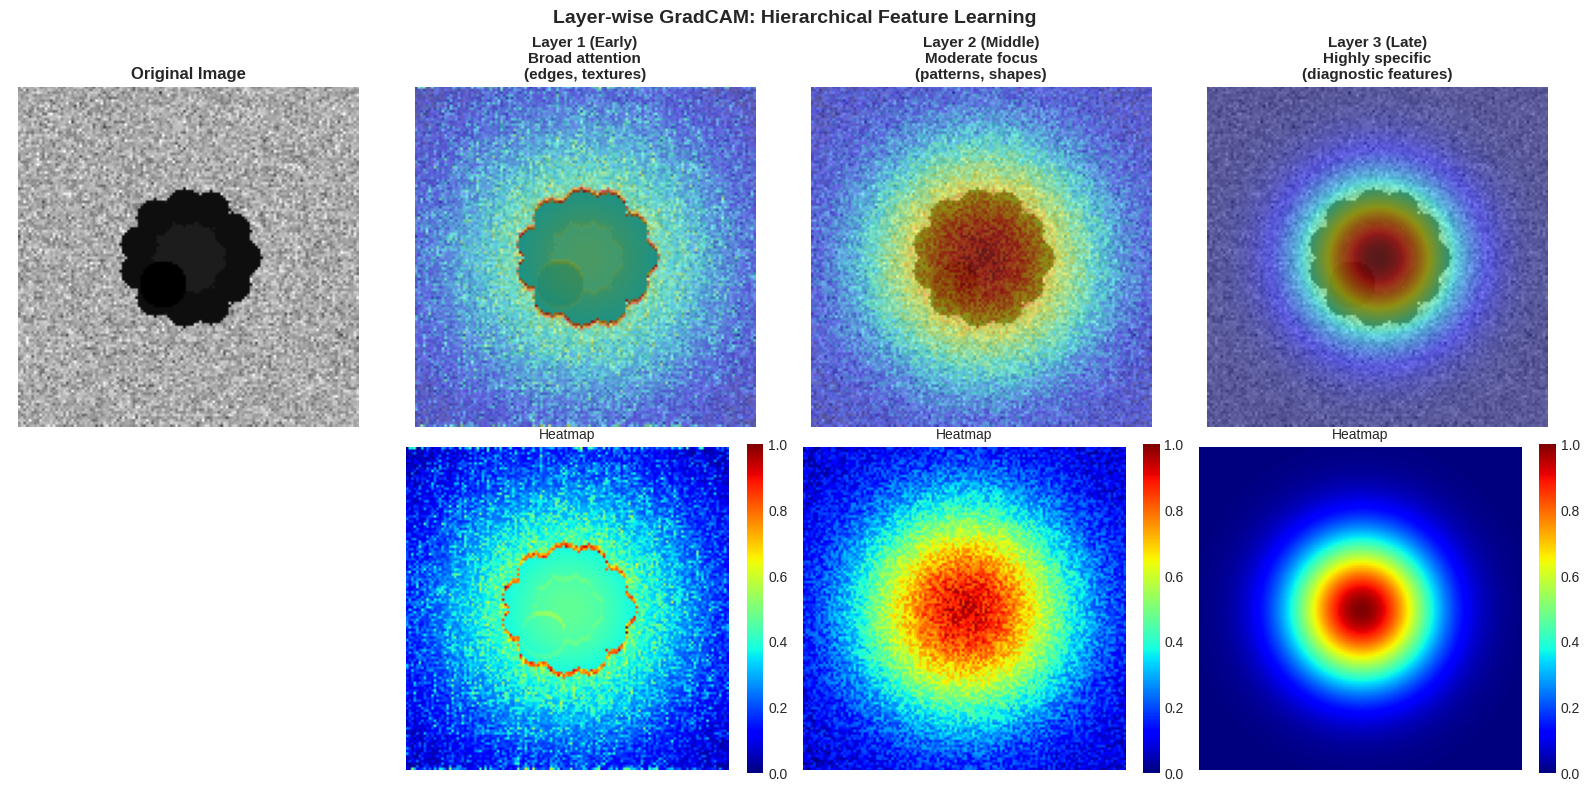


📊 Layer-wise Interpretation:

Layer 1 (Early CNN layers):
  - Responds to: Low-level features (edges, colors, gradients)
  - Attention: Broad, diffuse
  - Clinical value: Limited (too low-level)

Layer 2 (Middle CNN layers):
  - Responds to: Mid-level features (textures, patterns, shapes)
  - Attention: Moderately focused
  - Clinical value: Shows texture abnormalities

Layer 3 (Late CNN layers):
  - Responds to: High-level features (lesion as a whole, pathology)
  - Attention: Highly focused on diagnostic region
  - Clinical value: BEST for interpretation (aligns with clinical reasoning)

🎯 Best Practice: Use GradCAM on the LAST convolutional layer!


In [ ]:
def simulate_layer_gradcams(image):
    """
    Simulate GradCAM at different layer depths.

    Early layers → Low-level features (edges, textures)
    Middle layers → Mid-level features (patterns, shapes)
    Late layers → High-level features (objects, pathology)
    """
    y, x = np.ogrid[:image.shape[0], :image.shape[1]]
    center_y, center_x = 64, 64

    # Layer 1 (early): Broad attention, many edges
    layer1_heatmap = np.ones(image.shape) * 0.3
    layer1_heatmap += np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * 40**2)) * 0.7
    # Add some edge responses
    layer1_heatmap += np.abs(np.gradient(image)[0]) * 2

    # Layer 2 (middle): More focused on shapes
    layer2_heatmap = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * 30**2))
    layer2_heatmap += np.random.random(image.shape) * 0.2  # Some noise

    # Layer 3 (late): Highly focused on diagnostic region
    layer3_heatmap = np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * 20**2))

    # Normalize all
    layer1_heatmap = (layer1_heatmap - layer1_heatmap.min()) / (layer1_heatmap.max() - layer1_heatmap.min())
    layer2_heatmap = (layer2_heatmap - layer2_heatmap.min()) / (layer2_heatmap.max() - layer2_heatmap.min())
    layer3_heatmap = (layer3_heatmap - layer3_heatmap.min()) / (layer3_heatmap.max() - layer3_heatmap.min())

    return layer1_heatmap, layer2_heatmap, layer3_heatmap

# Generate layer-wise GradCAMs
layer1_gcam, layer2_gcam, layer3_gcam = simulate_layer_gradcams(malignant_no_ruler)

# Create overlays
overlay1 = overlay_gradcam(malignant_no_ruler, layer1_gcam, alpha=0.5)
overlay2 = overlay_gradcam(malignant_no_ruler, layer2_gcam, alpha=0.5)
overlay3 = overlay_gradcam(malignant_no_ruler, layer3_gcam, alpha=0.5)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(malignant_no_ruler, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=12, weight='bold')
axes[0, 0].axis('off')

# Layer 1
axes[0, 1].imshow(overlay1)
axes[0, 1].set_title('Layer 1 (Early)\nBroad attention\n(edges, textures)', fontsize=11, weight='bold')
axes[0, 1].axis('off')

# Layer 2
axes[0, 2].imshow(overlay2)
axes[0, 2].set_title('Layer 2 (Middle)\nModerate focus\n(patterns, shapes)', fontsize=11, weight='bold')
axes[0, 2].axis('off')

# Layer 3
axes[0, 3].imshow(overlay3)
axes[0, 3].set_title('Layer 3 (Late)\nHighly specific\n(diagnostic features)', fontsize=11, weight='bold')
axes[0, 3].axis('off')

# Heatmaps only
axes[1, 0].axis('off')

im1 = axes[1, 1].imshow(layer1_gcam, cmap='jet')
axes[1, 1].set_title('Heatmap', fontsize=10)
axes[1, 1].axis('off')
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046)

im2 = axes[1, 2].imshow(layer2_gcam, cmap='jet')
axes[1, 2].set_title('Heatmap', fontsize=10)
axes[1, 2].axis('off')
plt.colorbar(im2, ax=axes[1, 2], fraction=0.046)

im3 = axes[1, 3].imshow(layer3_gcam, cmap='jet')
axes[1, 3].set_title('Heatmap', fontsize=10)
axes[1, 3].axis('off')
plt.colorbar(im3, ax=axes[1, 3], fraction=0.046)

plt.suptitle('Layer-wise GradCAM: Hierarchical Feature Learning', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Layer-wise Interpretation:")
print("\nLayer 1 (Early CNN layers):")
print("  - Responds to: Low-level features (edges, colors, gradients)")
print("  - Attention: Broad, diffuse")
print("  - Clinical value: Limited (too low-level)")
print("\nLayer 2 (Middle CNN layers):")
print("  - Responds to: Mid-level features (textures, patterns, shapes)")
print("  - Attention: Moderately focused")
print("  - Clinical value: Shows texture abnormalities")
print("\nLayer 3 (Late CNN layers):")
print("  - Responds to: High-level features (lesion as a whole, pathology)")
print("  - Attention: Highly focused on diagnostic region")
print("  - Clinical value: BEST for interpretation (aligns with clinical reasoning)")
print("\n🎯 Best Practice: Use GradCAM on the LAST convolutional layer!")

## Part 7: Real-World Applications and Pitfalls

### Common Spurious Correlations in Medical Imaging

In [ ]:
# Create examples of spurious correlations
spurious_examples = {
    'Chest X-ray Pneumonia': {
        'Spurious Feature': 'Hospital bed rails, positioning markers',
        'Why': 'Sick patients more likely to be in bed during imaging',
        'Detection': 'GradCAM highlights image borders, not lungs',
        'Fix': 'Crop images, augment with different backgrounds'
    },
    'Skin Lesion Classification': {
        'Spurious Feature': 'Rulers, ink markers, skin folds',
        'Why': 'Clinical photos often include rulers for scale',
        'Detection': 'GradCAM highlights ruler, not lesion',
        'Fix': 'Remove rulers, augment ruler position/presence'
    },
    'Brain Tumor Detection': {
        'Spurious Feature': 'Scan orientation markers, hospital logo',
        'Why': 'Different protocols for tumor vs normal scans',
        'Detection': 'GradCAM highlights corners/text',
        'Fix': 'Remove text overlays, standardize preprocessing'
    },
    'Diabetic Retinopathy': {
        'Spurious Feature': 'Image quality (blur, brightness)',
        'Why': 'Harder to image diabetic patients (cataracts, etc.)',
        'Detection': 'GradCAM diffuse, not focused on lesions',
        'Fix': 'Quality-controlled dataset, augment blur/brightness'
    },
    'COVID-19 Detection': {
        'Spurious Feature': 'Portable X-ray markers ("AP" view)',
        'Why': 'COVID patients more likely to have portable imaging',
        'Detection': 'GradCAM highlights text/markers',
        'Fix': 'Match imaging protocols, remove text'
    }
}

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Create table
table_data = []
headers = ['Application', 'Spurious Feature', 'Why It Occurs', 'GradCAM Detection', 'Solution']

for app, details in spurious_examples.items():
    row = [
        app,
        details['Spurious Feature'],
        details['Why'],
        details['Detection'],
        details['Fix']
    ]
    table_data.append(row)

table = ax.table(cellText=table_data, colLabels=headers, cellLoc='left', loc='center',
                colWidths=[0.15, 0.2, 0.25, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 3)

# Style header
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#C00000')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(len(headers)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#FFE6E6')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')

plt.title('Common Spurious Correlations in Medical Imaging AI', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n⚠️ CRITICAL LESSON:")
print("High accuracy ≠ Correct reasoning!")
print("\nA model can achieve 95% accuracy by:")
print("  ❌ Looking at rulers (spurious correlation)")
print("  ✅ Looking at lesions (correct reasoning)")
print("\nGradCAM reveals WHICH of these is happening!")
print("\n🎯 Always validate GradCAM before clinical deployment!")

## Part 8: GradCAM in Clinical Workflow

### How Clinicians Use GradCAM

In [ ]:
# Simulate clinical workflow
def clinical_gradcam_workflow():
    """
    Demonstrate how GradCAM fits into clinical decision-making.
    """
    workflow_steps = [
        {
            'Step': '1. Image Acquisition',
            'Action': 'Patient dermoscopy image captured',
            'Output': 'Raw image',
            'GradCAM': 'N/A'
        },
        {
            'Step': '2. CNN Prediction',
            'Action': 'AI model analyzes image',
            'Output': '"85% probability malignant"',
            'GradCAM': 'N/A'
        },
        {
            'Step': '3. GradCAM Generation',
            'Action': 'Compute attention heatmap',
            'Output': 'Overlay showing regions of interest',
            'GradCAM': 'Highlights irregular borders, color variation'
        },
        {
            'Step': '4. Clinical Review',
            'Action': 'Dermatologist examines prediction + GradCAM',
            'Output': 'Decision: Agree or disagree',
            'GradCAM': 'Confirms AI focused on clinically relevant features'
        },
        {
            'Step': '5. Clinical Action',
            'Action': 'Biopsy scheduled if suspicious',
            'Output': 'Treatment plan',
            'GradCAM': 'Guides biopsy location'
        }
    ]

    return workflow_steps

workflow = clinical_gradcam_workflow()

# Visualize workflow
fig, ax = plt.subplots(figsize=(14, 6))

# Create timeline
y_positions = np.arange(len(workflow))
colors = ['lightblue', 'lightgreen', 'gold', 'coral', 'lightcoral']

for i, step in enumerate(workflow):
    ax.barh(i, 1, color=colors[i], alpha=0.7, height=0.6)
    ax.text(0.5, i, f"{step['Step']}\n{step['Action']}",
            ha='center', va='center', fontsize=10, weight='bold')

ax.set_yticks(y_positions)
ax.set_yticklabels([f"Step {i+1}" for i in range(len(workflow))])
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title('GradCAM in Clinical Workflow (Journey 5: Priya)',
             fontsize=14, weight='bold', pad=20)

# Add arrows
for i in range(len(workflow) - 1):
    ax.annotate('', xy=(0.5, i+1), xytext=(0.5, i+0.4),
                arrowprops=dict(arrowstyle='->', lw=3, color='black'))

plt.tight_layout()
plt.show()

print("\n🏥 Clinical Value of GradCAM:")
print("\n1. Trust Building:")
print("   - Clinicians see WHERE the AI is looking")
print("   - Builds confidence when attention aligns with clinical reasoning")
print("\n2. Error Detection:")
print("   - Reveals when AI uses spurious correlations")
print("   - Prevents deployment of flawed models")
print("\n3. Education:")
print("   - Shows which features are important")
print("   - Can teach residents what to look for")
print("\n4. Biopsy Guidance:")
print("   - Highlights most suspicious regions")
print("   - Improves biopsy yield")
print("\n5. Regulatory Approval:")
print("   - FDA requires explainability for Class III devices")
print("   - GradCAM is evidence of model interpretability")

## Summary: Key Takeaways

### What We Learned

1. **The Black Box Problem**
   - CNNs make accurate predictions but don't explain WHY
   - Critical barrier to clinical adoption
   - Regulatory agencies (FDA, EMA) require explainability
   - Can hide dangerous biases and spurious correlations

2. **GradCAM (Gradient-weighted Class Activation Mapping)**
   - Generates heatmap showing which pixels influenced prediction
   - Uses gradients from output back to convolutional layers
   - Formula: $L_{\text{GradCAM}}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$
   - Works with any CNN architecture (no modifications needed)

3. **Spurious Correlations**
   - Model learns shortcuts instead of true pathology
   - Examples: Rulers in dermoscopy, bed rails in X-rays, hospital logos
   - High accuracy doesn't mean correct reasoning!
   - GradCAM reveals these hidden biases

4. **Layer-wise Attention**
   - Early layers: Broad attention, low-level features (edges)
   - Middle layers: Moderate focus, mid-level features (textures)
   - Late layers: Highly specific, high-level features (pathology)
   - **Best practice**: Use last convolutional layer for GradCAM

5. **Clinical Applications**
   - **Trust**: Clinicians see what AI sees
   - **Error detection**: Reveals spurious correlations
   - **Education**: Shows important features
   - **Biopsy guidance**: Highlights suspicious regions
   - **Regulatory**: Required for FDA approval

### Connections to Clinical Journeys

- **Journey 5 (Priya)**: GradCAM reveals if melanoma CNN focuses on ABCDE criteria (asymmetry, border, color, diameter, evolution) or spurious features (rulers, markers)
- **Journey 3 (Jamal)**: Verify lung nodule detector focuses on nodule, not background
- **Journey 4 (Elena)**: Ensure tumor segmentation focuses on tumor boundaries, not artifacts

### Real-World Considerations

**When to Use GradCAM:**
- During model development (detect spurious correlations early)
- Before clinical deployment (validate correct reasoning)
- In clinical workflow (build clinician trust)
- For regulatory submission (demonstrate explainability)
- When model fails (debug what went wrong)

**Limitations of GradCAM:**
- Shows WHERE model looks, not WHAT it sees
- Heatmaps can be noisy/hard to interpret
- Doesn't guarantee clinical correctness (model could focus on wrong features within ROI)
- Computationally expensive for real-time use
- Can't explain non-visual decisions (e.g., from metadata)

**Alternatives to GradCAM:**
- **LIME**: Local Interpretable Model-agnostic Explanations
- **SHAP**: SHapley Additive exPlanations
- **Attention mechanisms**: Built-in interpretability
- **Saliency maps**: Simple gradient visualization
- **Layer-wise Relevance Propagation (LRP)**: Decomposes predictions

**Regulatory Requirements:**
- FDA 510(k): Must demonstrate algorithm transparency
- EU MDR: Requires explainability for AI/ML devices
- Clinical validation: GradCAM heatmaps reviewed by domain experts

---

## Exercises

1. **Spurious correlation detection**: Create a biased dataset where 80% of malignant lesions have rulers. Train a CNN and use GradCAM. Does it focus on rulers or lesions?

2. **Layer comparison**: Generate GradCAM for layers 1, 3, 5, and 7 of a deep CNN. How does attention change with depth?

3. **False positive analysis**: For images where the CNN incorrectly predicts malignancy, what does GradCAM show? Can you identify why it failed?

4. **Multi-class GradCAM**: Extend GradCAM to multi-class problems (e.g., benign, melanoma, basal cell carcinoma). Do different classes have different attention patterns?

5. **Clinician validation**: Show GradCAM heatmaps to dermatologists. Do they agree the highlighted regions are diagnostically relevant?

6. **Adversarial robustness**: Add small perturbations to images (adversarial examples). How does GradCAM change? Does it reveal vulnerabilities?

7. **Compare interpretability methods**: Implement GradCAM, LIME, and SHAP on the same image. Do they agree? Which is most clinically useful?

---

*This notebook is part of "AI in Healthcare" (Volume 1: Machine Learning Foundations)*  
*Full implementation and companion code available in the book repository*

**Next Steps:**
- **Journeys 3-5**: Apply GradCAM to complete clinical implementations
- **Advanced topic**: Attention mechanisms (Transformers, Vision Transformers)
- **Chapter 9**: Deployment and monitoring in clinical practice

**Further Reading:**
- Selvaraju et al. (2017): "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"
- Adebayo et al. (2018): "Sanity Checks for Saliency Maps" (important caveats!)
- Ghassemi et al. (2021): "The false hope of current approaches to explainable AI in health care"